In [1]:
import requests

#### 1. Data Acquisition
Use free public api MarketStack

In [ ]:
# basic end-of-day data
base_url = "https://api.marketstack.com/v1/eod"

params = {
    "access_key": "6df05ded06813ab154f3cc4c17133a78",
    "symbols": "AAPL" # stock data for Apple INC
}

try:
    response = requests.get(base_url, params=params)
    
    if response.status_code == 200:
        end_of_day = response.json()
            
    else:
        print(f"Failed: {response.status_code}")
        print(response.text)

except Exception as e:
    print(f"Error: {e}")

In [ ]:
print(end_of_day)
# Raw data is a python dict
# key 'data' has a list of stock values
# including date, open, high, low, close, volumn, etc.

# Let's see the closing price for Apple by day
for item in end_of_day.get('data', []):
    print(f"Date: {item['date']}, Close: {item['close']}")

{'pagination': {'limit': 100, 'offset': 0, 'count': 100, 'total': 100}, 'data': [{'open': 268.82, 'high': 270.49, 'low': 265.73, 'close': 267.46, 'volume': 44951600.0, 'adj_high': 270.49, 'adj_low': 265.73, 'adj_close': 267.46, 'adj_open': 268.815, 'adj_volume': 45018260.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'AAPL', 'exchange': 'XNAS', 'date': '2025-11-17T00:00:00+0000'}, {'open': 271.05, 'high': 275.96, 'low': 269.6, 'close': 272.41, 'volume': 47399300.0, 'adj_high': 275.96, 'adj_low': 269.6, 'adj_close': 272.41, 'adj_open': 271.05, 'adj_volume': 47431331.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'AAPL', 'exchange': 'XNAS', 'date': '2025-11-14T00:00:00+0000'}, {'open': 274.11, 'high': 276.7, 'low': 272.09, 'close': 272.95, 'volume': 49565800.0, 'adj_high': 276.699, 'adj_low': 272.09, 'adj_close': 272.95, 'adj_open': 274.11, 'adj_volume': 49602794.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'AAPL', 'exchange': 'XNAS', 'date': '2025-11-13T00:00:00+0000'}, {'

#### 2. Data Wrangling with Pandas

In [ ]:
import pandas as pd

df = pd.DataFrame(end_of_day['data'])

# Format Date
df['date'] = pd.to_datetime(df['date'])

# Sort by Date
df = df.sort_values('date', ascending=True)

# Reset index
df.reset_index(drop=True, inplace=True)

#columns_to_drop = ['name', 'exchange_code', 'asset_type', 'price_currency', 'symbol', 'exchange']

df.head()

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,201.890,203.2200,200.0000,201.08,73114100.0,203.2200,200.0000,201.08,201.890,73188571.0,1.0,0.0,AAPL,XNAS,2025-06-27 00:00:00+00:00
1,202.010,207.3900,199.2607,205.17,90651078.0,207.3900,199.2607,205.17,202.010,91912816.0,1.0,0.0,AAPL,XNAS,2025-06-30 00:00:00+00:00
2,206.665,210.1865,206.1401,207.82,77921627.0,210.1865,206.1401,207.82,206.665,78788867.0,1.0,0.0,AAPL,XNAS,2025-07-01 00:00:00+00:00
3,209.080,213.3400,208.1400,212.44,67834447.0,213.3400,208.1400,212.44,208.910,67941811.0,1.0,0.0,AAPL,XNAS,2025-07-02 00:00:00+00:00
4,212.145,214.6500,211.8101,213.55,34955836.0,214.6500,211.8101,213.55,212.145,34955836.0,1.0,0.0,AAPL,XNAS,2025-07-03 00:00:00+00:00


#### 3. Data Storytelling

In [17]:
# Question 1: What is the real return of this stock
total_return = (df['adj_close'].iloc[-1] / df['adj_close'].iloc[0]) -1
print(f"Cumulative Real Return for the period: {total_return * 100:.2f}%")

Cumulative Real Return for the period: 33.01%


In [ ]:
# Question 2: How about the Intraday Volatility?
df['volatility_pct'] = (df['high'] - df['low']) / df['open'] * 100
avg_vol = df['volatility_pct'].mean()
max_vol = df['volatility_pct'].max()

print(f"\nAverage Intraday Volatility: {avg_vol:.2f}%")
print(f"Max Single-Day Volatility: {max_vol:.2f}%")


Average Intraday Volatility: 1.90%
Max Single-Day Volatility: 5.73%


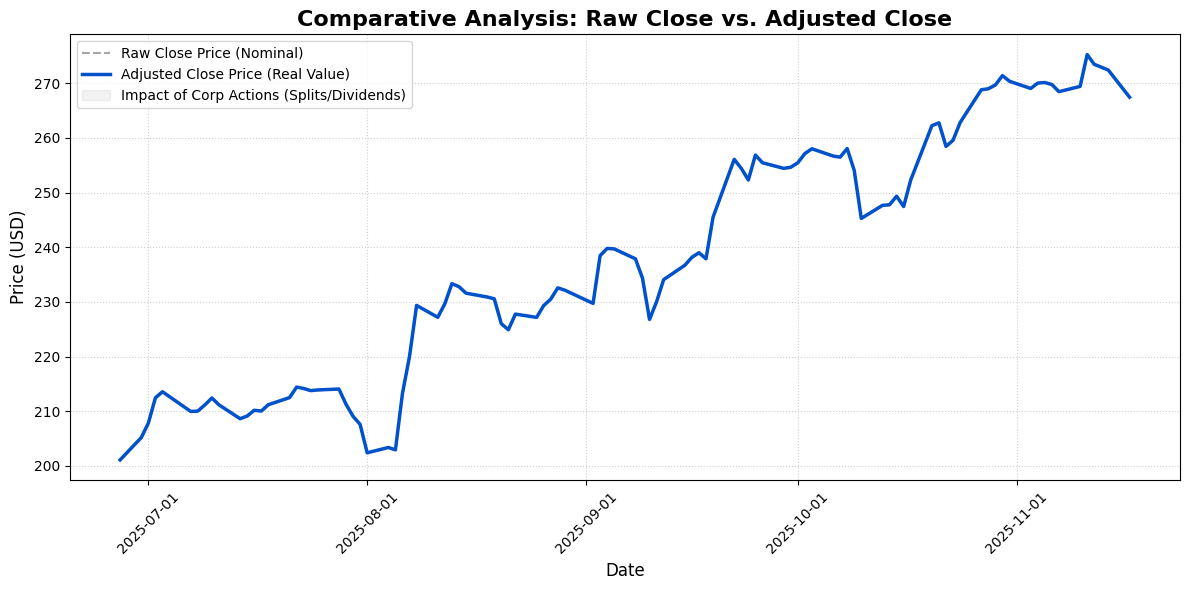

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6), dpi=100)

plt.plot(df['date'], df['close'], 
         label='Raw Close Price (Nominal)', 
         color='gray', 
         linestyle='--', 
         linewidth=1.5,
         alpha=0.7)

plt.plot(df['date'], df['adj_close'], 
         label='Adjusted Close Price (Real Value)', 
         color='#0052cc',  # Professional deep blue
         linestyle='-', 
         linewidth=2.5)

# Fill the area between the two lines (if exists)
plt.fill_between(df['date'], df['close'], df['adj_close'], 
                 color='gray', 
                 alpha=0.1, 
                 label='Impact of Corp Actions (Splits/Dividends)')

# Styling and Formatting
plt.title('Comparative Analysis: Raw Close vs. Adjusted Close', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid(True, which='major', linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=10, frameon=True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [25]:
dividends = df[df['dividend'] > 0]

if not dividends.empty:
    print("\nDividends hisroty:")
    print(dividends[['date', 'dividend']])
    print(f"Sum of dividends: ${dividends['dividend'].sum()}")
else:
    print("\nNo dividend records in this period.")


splits = df[df['split_factor'] != 1]

if not splits.empty:
    print("\Split history:")
    print(splits[['date', 'split_factor']])
else:
    print("\nNo split records in this period.")


Dividends hisroty:
                        date  dividend
30 2025-08-11 00:00:00+00:00      0.26
94 2025-11-10 00:00:00+00:00      0.26
Sum of dividends: $0.52

No split records in this period.


Though there have two dividends in this period, however, the sum of dividends is too small (compared with the regular closing price) to be observed in the plot above.

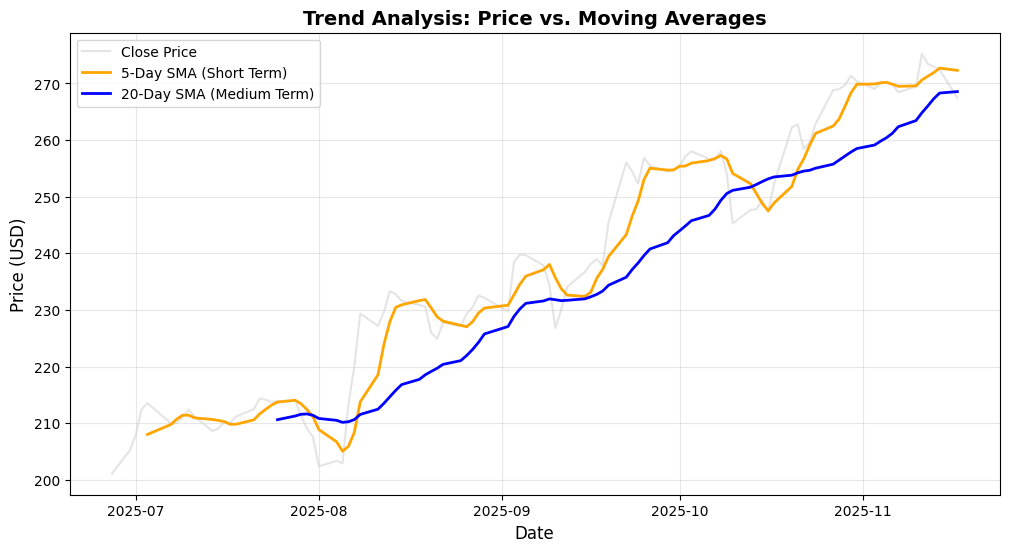

In [ ]:
# Calculate a Short-term Moving Average (5 days)
df['SMA_5'] = df['close'].rolling(window=5).mean()

# Calculate a Medium-term Moving Average (20 days)
df['SMA_20'] = df['close'].rolling(window=20).mean()

# Visualization: Price vs. Trends

plt.plot(df['date'], df['close'], label='Close Price', color='lightgray', linewidth=1.5, alpha=0.6)
plt.plot(df['date'], df['SMA_5'], label='5-Day SMA (Short Term)', color='orange', linewidth=2)
plt.plot(df['date'], df['SMA_20'], label='20-Day SMA (Medium Term)', color='blue', linewidth=2)

plt.title('Trend Analysis: Price vs. Moving Averages', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 4. Summary
The trend chart confirms a steady upward momentum, with the price rising from ~$200 to ~$270 and the short-term moving average (Orange) staying consistently above the medium-term one (Blue). The statistics reveal a massive 33.01% cumulative return and generally stable trading (1.90% average volatility), though there was one specific day with a sharp 5.73% swing. 

The most surprising aspect is the sheer insignificance of the dividends compared to the price growth. Despite the code confirming that Apple paid out cash twice, the "Comparative Analysis" chart shows the Raw Price and Adjusted Price lines overlapping perfectly. This reveals a stark reality: in this timeframe, the stock generated a 33% return from price appreciation, while the dividends contributed only about 0.2% (approx $0.52 on a $250 stock). It is a perfect visual example of how, for modern tech giants, "Growth" completely eclipses "Income," making the dividend adjustment mathematically real but visually invisible.